<div style="display:flex; align-items:center; justify-content:space-between; gap:24px; border-bottom:1px solid #d0d7de; padding-bottom:12px; margin-bottom:18px;">
  <div>
    <h1 style="margin:0;">Infraestructuras Computacionales para el Procesamiento de datos masivos</h1>
    <p style="margin:6px 0 0 0;"><strong>Ejercicio 2.1, Modulo 2 Tema 1</strong></p>
  </div>
  <img src="https://www.uned.es/universidad/.imaging/mte/site-facultades-theme/220/dam/recursos-corporativos/logotipos/facultades-escuelas/logo_informatica.gif/jcr:content/logo_informatica.gif" alt="Logo ETSI Informatica UNED" style="height:72px; width:auto;" />
</div>

Este cuaderno muestra cómo cargar y explorar el dataset `heart.csv` usando PySpark. Asegúrate de tener el archivo `heart.csv` en el mismo directorio que este cuaderno para que funcione correctamente. El dataset contiene información sobre pacientes y si tienen o no enfermedad cardíaca, junto con varias características como edad, presión arterial, colesterol, etc. Vamos a cargar el dataset, explorar su estructura y realizar algunas operaciones básicas para entender mejor los datos.

In [1]:
!pip install pyspark
!pip install findspark


In [13]:
import findspark
findspark.init()

In [3]:
from pyspark.sql import SparkSession



El primer paso es crear una sesión de Spark, que es el punto de entrada para trabajar con PySpark. Luego, cargamos el dataset `heart.csv` en un DataFrame de Spark y mostramos las primeras filas para tener una idea de cómo se ven los datos. Después, exploramos el esquema del DataFrame para entender los tipos de datos de cada columna. También realizamos un conteo por clase de enfermedad cardíaca para ver cuántos pacientes tienen o no la enfermedad. Finalmente, mostramos algunas estadísticas descriptivas para las columnas numéricas del dataset.

El fichero 'heart.csv' está disponible en: https://www.kaggle.com/datasets/algozee/heart-decices?resource=download o en el portal docente

In [12]:
spark = SparkSession.builder.appName("Enfermedad Corazon").getOrCreate()

In [5]:
# Cargar el dataset (asegúrate de tener heart.csv en el mismo directorio)

df = spark.read.csv("heart.csv", header=True, inferSchema=True)
df.show(5)

+------+---+---+---------------+---+-----------+------------+-----------+------+---------------+-------------+-----------+-----------------------+--------+
|    id|Age|Sex|Chest pain type| BP|Cholesterol|FBS over 120|EKG results|Max HR|Exercise angina|ST depression|Slope of ST|Number of vessels fluro|Thallium|
+------+---+---+---------------+---+-----------+------------+-----------+------+---------------+-------------+-----------+-----------------------+--------+
|630000| 58|  1|              3|120|        288|           0|          2|   145|              1|          0.8|          2|                      3|       3|
|630001| 55|  0|              2|120|        209|           0|          0|   172|              0|          0.0|          1|                      0|       3|
|630002| 54|  1|              4|120|        268|           0|          0|   150|              1|          0.0|          2|                      3|       7|
|630003| 44|  0|              3|112|        177|           0|   

In [6]:
# Ver el esquema del DataFrame
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Sex: integer (nullable = true)
 |-- Chest pain type: integer (nullable = true)
 |-- BP: integer (nullable = true)
 |-- Cholesterol: integer (nullable = true)
 |-- FBS over 120: integer (nullable = true)
 |-- EKG results: integer (nullable = true)
 |-- Max HR: integer (nullable = true)
 |-- Exercise angina: integer (nullable = true)
 |-- ST depression: double (nullable = true)
 |-- Slope of ST: integer (nullable = true)
 |-- Number of vessels fluro: integer (nullable = true)
 |-- Thallium: integer (nullable = true)



In [7]:
# Conteo por clase HeartDisease
df.groupBy("Age").count().show()

+---+-----+
|Age|count|
+---+-----+
| 65| 7531|
| 53| 6764|
| 34| 1124|
| 76|  307|
| 44|10979|
| 47| 2935|
| 52|13034|
| 40| 2012|
| 57|13669|
| 54|19977|
| 48| 7047|
| 64| 8625|
| 41|10417|
| 43| 6937|
| 37| 1071|
| 61| 5941|
| 35| 1737|
| 55| 4979|
| 59|13593|
| 39| 2322|
+---+-----+
only showing top 20 rows



In [11]:
# Filtrar registros con enfermedad cardíaca
df.filter(df.Age == 65).show(5)

+------+---+---+---------------+---+-----------+------------+-----------+------+---------------+-------------+-----------+-----------------------+--------+
|    id|Age|Sex|Chest pain type| BP|Cholesterol|FBS over 120|EKG results|Max HR|Exercise angina|ST depression|Slope of ST|Number of vessels fluro|Thallium|
+------+---+---+---------------+---+-----------+------------+-----------+------+---------------+-------------+-----------+-----------------------+--------+
|630035| 65|  0|              3|140|        256|           0|          0|   165|              0|          0.0|          1|                      1|       3|
|630052| 65|  1|              4|136|        233|           0|          2|    96|              0|          2.0|          3|                      0|       7|
|630089| 65|  1|              4|130|        282|           0|          2|   105|              0|          1.0|          2|                      3|       7|
|630125| 65|  1|              4|140|        196|           0|   

In [12]:
# Estadísticas descriptivas
df.describe().show()

26/06/22 12:58:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+-----------------+-------------------+------------------+------------------+------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+-----------------------+------------------+
|summary|               id|              Age|                Sex|   Chest pain type|                BP|       Cholesterol|       FBS over 120|       EKG results|            Max HR|    Exercise angina|     ST depression|       Slope of ST|Number of vessels fluro|          Thallium|
+-------+-----------------+-----------------+-------------------+------------------+------------------+------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+-----------------------+------------------+
|  count|           270000|           270000|             270000|            270000|            270000|            270000|             270000|            

In [13]:
# Seleccionar columnas numéricas y mostrar resumen
numeric_cols = ["Age", "Sex", "BP",  "Cholesterol"]
df.select(numeric_cols).summary().show()

+-------+-----------------+-------------------+------------------+------------------+
|summary|              Age|                Sex|                BP|       Cholesterol|
+-------+-----------------+-------------------+------------------+------------------+
|  count|           270000|             270000|            270000|            270000|
|   mean|54.15987037037037| 0.7163148148148148| 130.5550888888889|245.04527037037036|
| stddev|8.255470991401232|0.45078670512369207|15.007907772998319| 33.69545804342384|
|    min|               29|                  0|                94|               126|
|    25%|               48|                  0|               120|               223|
|    50%|               54|                  1|               130|               243|
|    75%|               60|                  1|               140|               269|
|    max|               77|                  1|               200|               564|
+-------+-----------------+-------------------+-------

In [14]:
# Finalizar la sesión Spark
spark.stop()

## Solución de ejercicios propuestos - Lección 7

Esta sección resuelve los ejercicios propuestos de la lección **Ejecución de ejemplo de Spark**. Las soluciones combinan comandos de terminal, código PySpark y criterios de análisis para interpretar lo observado en Spark UI, logs y tiempos de ejecución.

> Nota: los comandos con `docker compose` y `spark-submit` deben ejecutarse desde la carpeta donde se encuentre el laboratorio Spark correspondiente. Si se trabaja únicamente desde Jupyter, puede usarse el código PySpark como referencia y adaptar las rutas locales.


### Ejercicio 1 - Ejecutar un ejemplo con `spark-submit`

**Objetivo:** lanzar una aplicación Spark fuera de la consola interactiva y documentar driver, executors y stages en Spark UI.

La solución consiste en crear una aplicación PySpark sencilla, ejecutarla con `spark-submit` y observar la ejecución en la interfaz web de Spark. En modo local, el driver se ejecuta en la misma máquina. En un clúster Standalone, el driver coordina el job y los executors ejecutan las tareas distribuidas.


In [1]:
from pathlib import Path

app_code = """
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark import SparkFiles
from time import time

spark = SparkSession.builder.appName("M2T1L7_spark_submit_demo").getOrCreate()

inicio = time()
df = spark.read.csv(SparkFiles.get("heart.csv"), header=True, inferSchema=True)

resultado = (df
    .filter(F.col("Age") >= 50)
    .groupBy("Age")
    .agg(
        F.count("*").alias("registros"),
        F.avg("Cholesterol").alias("colesterol_medio"),
        F.avg("BP").alias("bp_media")
    )
    .orderBy("Age"))

resultado.show(50, truncate=False)
print("Filas procesadas:", df.count())
print("Particiones:", df.rdd.getNumPartitions())
print("Tiempo total:", round(time() - inicio, 2), "segundos")

spark.stop()
"""

Path("app_m2t1l7_submit.py").write_text(app_code, encoding="utf-8")
print("Aplicación creada: app_m2t1l7_submit.py")


Aplicación creada: app_m2t1l7_submit.py


In [3]:
# Ejecución local desde el notebook o terminal:
# !spark-submit --master 'local[2]' --files heart.csv app_m2t1l7_submit.py

# Ejecución en un clúster Spark Standalone local:
!spark-submit \
  --master spark://127.0.0.1:7077 \
  --conf spark.driver.host=127.0.0.1 \
  --files heart.csv \
  app_m2t1l7_submit.py


26/06/29 12:57:13 WARN Utils: Your hostname, Maquito.local resolves to a loopback address: 127.0.0.1; using 192.168.68.62 instead (on interface en0)
26/06/29 12:57:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/06/29 12:57:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/29 12:57:14 INFO SparkContext: Running Spark version 3.5.1
26/06/29 12:57:14 INFO SparkContext: OS info Mac OS X, 26.5.1, aarch64
26/06/29 12:57:14 INFO SparkContext: Java version 17.0.19
26/06/29 12:57:14 INFO ResourceUtils: ==============================================================
26/06/29 12:57:14 INFO ResourceUtils: No custom resources configured for spark.driver.
26/06/29 12:57:14 INFO ResourceUtils: ==============================================================
26/06/29 12:57:14 INFO SparkContext: Submitted application: M2T1L7_spark_submit_demo
26/06/29 12:57:14 INFO ResourceProfile: Default Reso

**Qué documentar en Spark UI:**

- **Driver:** proceso que ejecuta el programa principal, crea la `SparkSession`, construye el plan de ejecución y coordina las tareas.
- **Executors:** procesos que ejecutan tareas sobre particiones de datos. En modo local pueden verse como hilos del mismo proceso; en Standalone se reparten entre workers.

- **Jobs:** acciones lanzadas por operaciones como `show()` o `count()`.
- **Stages:** fases separadas por operaciones que requieren shuffle, por ejemplo `groupBy`.
- **Tasks:** unidades de trabajo ejecutadas sobre particiones.

**Resultado esperado:** la aplicación debe generar al menos un job para `show()` y otro para `count()`. La agregación por edad genera stages porque Spark necesita agrupar registros por clave.

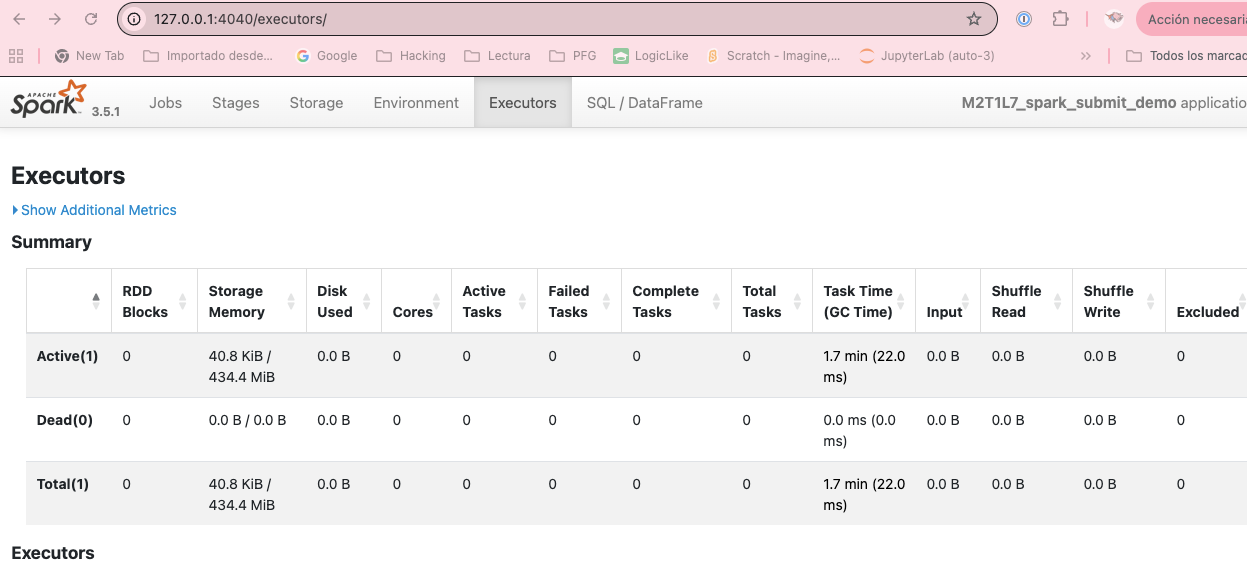

### Ejercicio 2 - Escalar un entorno Standalone a varios workers

**Objetivo:** comprobar si al aumentar el número de workers mejora la distribución de tareas.

En un clúster Standalone con Docker Compose, se puede escalar el servicio de workers. El beneficio solo se observa si el job tiene suficientes particiones y si la máquina anfitriona dispone de CPU/memoria suficientes.


In [ ]:
# Comandos de terminal desde la carpeta del docker-compose.yml:
# !docker compose up -d --scale spark-worker=4
# !docker compose ps


In [ ]:
# Job con suficientes particiones para observar distribución de tareas.
# Puede ejecutarse en PySpark local o adaptarse a spark-submit.
from pyspark.sql import SparkSession
from time import time

spark = SparkSession.builder.appName("M2T1L7_escalado_workers").getOrCreate()

inicio = time()
rdd = spark.sparkContext.parallelize(range(5_000_000), 64)
resultado = rdd.map(lambda x: x * x).sum()
fin = time()

print("Resultado:", resultado)
print("Particiones:", rdd.getNumPartitions())
print("Tiempo aproximado:", round(fin - inicio, 2), "segundos")


**Análisis esperado:**

- Con más workers, Spark puede repartir tareas entre más ejecutores.
- Si el número de particiones es bajo, algunos workers pueden quedar infrautilizados.
- Si el dataset es pequeño, el tiempo puede no reducirse porque el coste de planificación y comunicación domina.
- La Spark UI debe mostrar más executors activos cuando el clúster Standalone tiene más workers disponibles.


### Ejercicio 3 - Reducir memoria de executor

**Objetivo:** analizar el efecto de limitar memoria sobre tiempo, spills o errores.

Para provocar presión de memoria se puede reducir la memoria del worker/executor y ejecutar una operación con shuffle, como `groupBy`, `sort` o `join`. Si la memoria no es suficiente, Spark puede escribir datos temporales a disco (*spill*) o fallar con errores de memoria.


In [ ]:
# Ejemplo de configuración en docker-compose.yml para un worker limitado:
# environment:
#   - SPARK_WORKER_MEMORY=512m
#   - SPARK_WORKER_CORES=1

# Después de modificar la configuración:
# !docker compose down
# !docker compose up -d --scale spark-worker=2


In [ ]:
from pyspark.sql import functions as F

# Operación con shuffle para observar presión de memoria.
df_mem = spark.range(0, 3_000_000, 1, 48).withColumn("grupo", F.col("id") % 1000)

resumen_mem = (df_mem
    .groupBy("grupo")
    .agg(
        F.count("*").alias("registros"),
        F.sum("id").alias("suma_id")
    )
    .orderBy("grupo"))

resumen_mem.show(20)


**Qué observar:**

- Mayor duración de stages con shuffle.
- Posibles métricas de spill en Spark UI si Spark necesita usar disco.
- Reintentos de tareas si un executor falla.
- Errores `OutOfMemoryError` si la memoria asignada es claramente insuficiente.

**Conclusión:** reducir memoria no cambia el resultado lógico del job, pero puede empeorar mucho el rendimiento o impedir que la aplicación termine.


### Ejercicio 4 - Consultar logs del master y workers

**Objetivo:** localizar en logs el inicio de la aplicación, la asignación de recursos y la finalización del job.


In [ ]:
# Comandos útiles en Docker Compose:
# !docker compose logs spark-master --tail=120
# !docker compose logs spark-worker --tail=120

# Si existen varios workers escalados, se puede consultar el nombre concreto del contenedor:
# !docker compose ps
# !docker logs NOMBRE_DEL_CONTENEDOR --tail=120


**Patrones que se deben identificar:**

- Registro de workers en el master.
- Recepción de la aplicación enviada mediante `spark-submit`.
- Asignación de cores y memoria a executors.
- Creación y parada de executors.
- Finalización de la aplicación con estado correcto o error.

**Interpretación:** los logs complementan la Spark UI. La UI muestra métricas de ejecución; los logs permiten confirmar decisiones del gestor del clúster y diagnosticar problemas de arranque, conectividad o recursos.


### Ejercicio 5 - Comparativa Standalone, YARN y Kubernetes

**Objetivo:** comparar los gestores de clúster desde el punto de vista de un laboratorio docente.


| Criterio | Standalone | YARN | Kubernetes |
|---|---|---|---|
| Facilidad de instalación | Alta. Es el gestor nativo de Spark y requiere pocos componentes. | Media/baja. Requiere entorno Hadoop configurado. | Media. Requiere conocer contenedores, pods, imágenes y permisos. |
| Adecuación para docencia | Muy alta para primeros laboratorios Spark. | Adecuado si el curso incluye Hadoop/HDFS/YARN. | Adecuado para docencia cloud-native o despliegues modernos. |
| Dependencias | Spark y máquinas worker. | Hadoop, ResourceManager y NodeManagers. | Clúster Kubernetes e imágenes Docker. |
| Gestión de recursos | Simple, menos sofisticada. | Robusta para entornos Hadoop multiusuario. | Robusta y portable en entornos contenerizados. |
| Escalabilidad | Buena para laboratorios y clústeres dedicados. | Buena en grandes plataformas Hadoop. | Muy buena en cloud, híbrido y microservicios. |
| Observabilidad | Spark UI y logs del master/workers. | Spark UI, YARN UI y logs de contenedores. | Spark UI, logs de pods y herramientas Kubernetes. |
| Caso recomendado | Prácticas locales, docencia inicial y pruebas rápidas. | Organizaciones con Hadoop existente. | Plataformas modernas basadas en contenedores. |


**Conclusión:** para un laboratorio docente inicial, **Standalone** suele ser la opción más sencilla y controlable. **YARN** es útil cuando se quiere enseñar integración con Hadoop empresarial. **Kubernetes** es preferible cuando el objetivo es acercar Spark a arquitecturas cloud-native y despliegues reproducibles con contenedores.
